# Unsupervised clustering and conductance of ResNet-18 embeddings

This notebook replaces the supervised phase classifier with unsupervised clustering. It compares:

- MiniBatch K-means on the PCA space retaining at least 90% of variance;
- MiniBatch K-means directly on all 512 frozen ResNet features.

Both models see all 310,000 configurations. Temperature and magnetization are used only **after fitting** to interpret the clusters.

For conductance, a 30-nearest-neighbor affinity graph is constructed from the 31,000 seed–temperature mean embeddings. This contains every independent seed and temperature while avoiding an impossible 310,000² dense overlap matrix.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EMBEDDING_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_embeddings.npy"
TEMPERATURE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_temperatures.npy"
MAGNETIZATION_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_signed_magnetization.npy"

assert EMBEDDING_PATH.exists(), "Run ising16_magnetization.ipynb first to create raw ResNet embeddings."
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
embedding_temperatures = np.load(TEMPERATURE_PATH)
assert embeddings.shape == (N_CONFIGURATIONS, 512)

run_dirs = sorted(
    DATA_ROOT.glob("ising16_tc_[0-9]*"),
    key=lambda path: int(path.name.rsplit("_", 1)[1]),
)
assert len(run_dirs) == N_RUNS

temperature_grid = embedding_temperatures.reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE
)
temperatures = temperature_grid[0, :, 0]
assert np.all(temperature_grid == temperatures[None, :, None])

print(f"Embeddings: {embeddings.shape}")
print(f"Temperatures: {temperatures[0]:g} to {temperatures[-1]:g}")

Embeddings: (310000, 512)
Temperatures: 1.5 to 3


In [2]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

SCORES_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_scores.npy"
PCA_METADATA_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_metadata.json"
MAGNETIZATION_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_signed_magnetization.npy"

with open(PCA_METADATA_PATH) as handle:
    pca_metadata = json.load(handle)
n_components_90 = pca_metadata["n_components_90"]
pca90_scores = np.load(SCORES_PATH, mmap_mode="r")
signed_magnetization = np.load(MAGNETIZATION_PATH)
abs_magnetization = np.abs(signed_magnetization)

assert pca90_scores.shape == (N_CONFIGURATIONS, n_components_90)
print(f"PCA clustering dimensions: {n_components_90}")

PCA clustering dimensions: 22


## Cluster all configurations

Three clusters are requested because raw, non-inverted Ising configurations can naturally express two oppositely magnetized ordered groups plus a disordered group. This is a structural choice, not a temperature label; the algorithm receives no physical observables.

In [3]:
N_CLUSTERS = 3
CLUSTER_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_cluster_labels.npz"

if CLUSTER_PATH.exists():
    cluster_cache = np.load(CLUSTER_PATH)
    pca_clusters = cluster_cache["pca_clusters"]
    full_clusters = cluster_cache["full_clusters"]
else:
    pca_clusterer = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        batch_size=8_192,
        n_init=10,
        max_iter=300,
        random_state=42,
    )
    pca_clusters = pca_clusterer.fit_predict(np.asarray(pca90_scores))

    full_clusterer = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        batch_size=8_192,
        n_init=10,
        max_iter=300,
        random_state=42,
    )
    full_clusters = full_clusterer.fit_predict(np.asarray(embeddings))
    np.savez(CLUSTER_PATH, pca_clusters=pca_clusters, full_clusters=full_clusters)

print("PCA cluster sizes:", np.bincount(pca_clusters))
print("Full-embedding cluster sizes:", np.bincount(full_clusters))
print(
    "Agreement between clusterings (adjusted mutual information):",
    f"{adjusted_mutual_info_score(pca_clusters, full_clusters):.3f}",
)

PCA cluster sizes: [145099  88373  76528]
Full-embedding cluster sizes: [ 86613 149192  74195]
Agreement between clusterings (adjusted mutual information): 0.926


## Post-hoc cluster interpretation

Temperature and magnetization did not enter either clustering fit. They are introduced here only to determine what structures the clusters discovered.

In [4]:
def summarize_clusters(labels, method):
    rows = []
    for cluster in np.unique(labels):
        mask = labels == cluster
        rows.append({
            "method": method,
            "cluster": int(cluster),
            "size": int(mask.sum()),
            "fraction": float(mask.mean()),
            "mean_temperature": float(embedding_temperatures[mask].mean()),
            "mean_signed_m": float(signed_magnetization[mask].mean()),
            "mean_abs_m": float(abs_magnetization[mask].mean()),
        })
    return pd.DataFrame(rows)

cluster_summary = pd.concat([
    summarize_clusters(pca_clusters, "PCA 90%"),
    summarize_clusters(full_clusters, "Full 512-D"),
], ignore_index=True)
cluster_summary.to_csv(OUTPUT_ROOT / "ising16_resnet18_raw_cluster_summary.csv", index=False)
cluster_summary

,method,cluster,size,fraction,mean_temperature,mean_signed_m,mean_abs_m
0,PCA 90%,0,145099,0.468061,2.495658,0.006701,0.413244
1,PCA 90%,1,88373,0.285074,2.029270,-0.775309,0.887696
2,PCA 90%,2,76528,0.246865,2.077015,0.878306,0.878307
3,Full 512-D,0,86613,0.279397,2.029918,-0.792754,0.888635
4,Full 512-D,1,149192,0.481265,2.489605,0.018049,0.422384
5,Full 512-D,2,74195,0.239339,2.064203,0.884709,0.884709


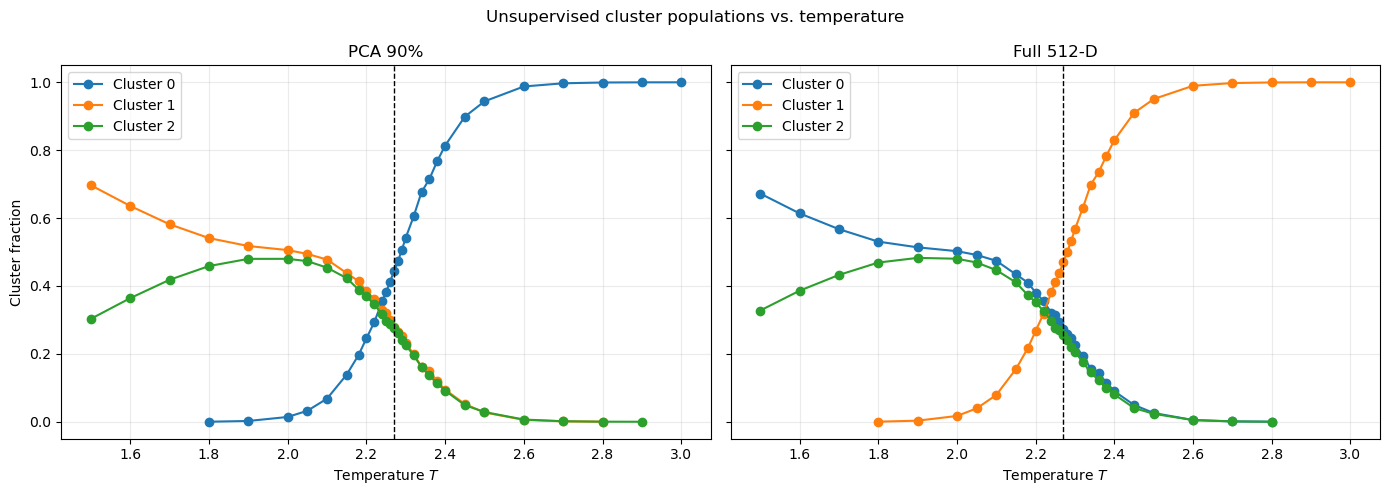

In [5]:
def cluster_fraction_by_temperature(labels, method):
    frame = pd.DataFrame({
        "temperature": embedding_temperatures,
        "cluster": labels,
    })
    counts = frame.groupby(["temperature", "cluster"]).size().rename("count").reset_index()
    counts["fraction"] = counts["count"] / counts.groupby("temperature")["count"].transform("sum")
    counts["method"] = method
    return counts

fraction_table = pd.concat([
    cluster_fraction_by_temperature(pca_clusters, "PCA 90%"),
    cluster_fraction_by_temperature(full_clusters, "Full 512-D"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, method in zip(axes, ("PCA 90%", "Full 512-D")):
    method_data = fraction_table[fraction_table["method"] == method]
    for cluster in sorted(method_data["cluster"].unique()):
        data = method_data[method_data["cluster"] == cluster]
        axis.plot(data["temperature"], data["fraction"], "o-", label=f"Cluster {cluster}")
    axis.axvline(2.0 / np.log(1.0 + np.sqrt(2.0)), color="black", linestyle="--", linewidth=1)
    axis.set(xlabel="Temperature $T$", title=method)
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel("Cluster fraction")
fig.suptitle("Unsupervised cluster populations vs. temperature")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_cluster_fractions.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

## Sparse affinity conductance

The following is the scalable counterpart of the earlier dense-overlap calculation. For each node, the pointwise escape score is

$$1-\\frac{\\sum_{j\\in C_i}w_{ij}}{\\sum_jw_{ij}},$$

where $C_i$ is the node's assigned cluster. Standard global cluster conductance is also reported as cut weight divided by the smaller of cluster and complement volume.

In [6]:
seed_temperature_pca = np.asarray(pca90_scores).reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE, n_components_90
).mean(axis=2).reshape(-1, n_components_90)
seed_temperature_full = np.asarray(embeddings).reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE, 512
).mean(axis=2).reshape(-1, 512)
graph_temperatures = temperature_grid[:, :, 0].reshape(-1)

def nearest_centroid_labels(points, configuration_features, configuration_labels):
    centroids = np.vstack([
        configuration_features[configuration_labels == cluster].mean(axis=0)
        for cluster in range(N_CLUSTERS)
    ])
    point_norm = np.sum(points ** 2, axis=1, keepdims=True)
    center_norm = np.sum(centroids ** 2, axis=1)[None, :]
    distances = point_norm + center_norm - 2 * points @ centroids.T
    return distances.argmin(axis=1)

graph_pca_labels = nearest_centroid_labels(
    seed_temperature_pca, np.asarray(pca90_scores), pca_clusters
)
graph_full_labels = nearest_centroid_labels(
    seed_temperature_full, np.asarray(embeddings), full_clusters
)

def affinity_conductance(features, labels, n_neighbors=30):
    neighbors = NearestNeighbors(n_neighbors=n_neighbors + 1, n_jobs=-1)
    neighbors.fit(features)
    distances, indices = neighbors.kneighbors(features)
    distances = distances[:, 1:]
    indices = indices[:, 1:]
    local_scale = np.median(distances[distances > 0])
    weights = np.exp(-(distances ** 2) / (2 * local_scale ** 2 + 1e-12))

    same_cluster = labels[indices] == labels[:, None]
    within_fraction = (weights * same_cluster).sum(axis=1) / weights.sum(axis=1)
    pointwise_escape = 1.0 - within_fraction

    global_rows = []
    total_volume = weights.sum()
    for cluster in np.unique(labels):
        in_cluster = labels == cluster
        cluster_volume = weights[in_cluster].sum()
        complement_volume = total_volume - cluster_volume
        cut_weight = (
            weights[in_cluster] * (labels[indices[in_cluster]] != cluster)
        ).sum()
        conductance = cut_weight / max(min(cluster_volume, complement_volume), 1e-12)
        global_rows.append({
            "cluster": int(cluster),
            "conductance": float(conductance),
            "cut_weight": float(cut_weight),
            "cluster_volume": float(cluster_volume),
        })
    return pointwise_escape, pd.DataFrame(global_rows)

pca_escape, pca_global_conductance = affinity_conductance(
    seed_temperature_pca, graph_pca_labels
)
full_escape, full_global_conductance = affinity_conductance(
    seed_temperature_full, graph_full_labels
)
pca_global_conductance["method"] = "PCA 90%"
full_global_conductance["method"] = "Full 512-D"
global_conductance = pd.concat(
    [pca_global_conductance, full_global_conductance], ignore_index=True
)
global_conductance.to_csv(
    OUTPUT_ROOT / "ising16_resnet18_raw_global_conductance.csv", index=False
)
global_conductance

,cluster,conductance,cut_weight,cluster_volume,method
0,0,0.026537,5763.126857,346525.339416,PCA 90%
1,1,0.064512,8522.476208,132107.419686,PCA 90%
2,2,0.101463,8630.913470,85064.314669,PCA 90%
3,0,0.069311,9219.493979,133016.685159,Full 512-D
4,1,0.027185,5932.108692,352011.269054,Full 512-D
5,2,0.110029,9373.857303,85194.637540,Full 512-D


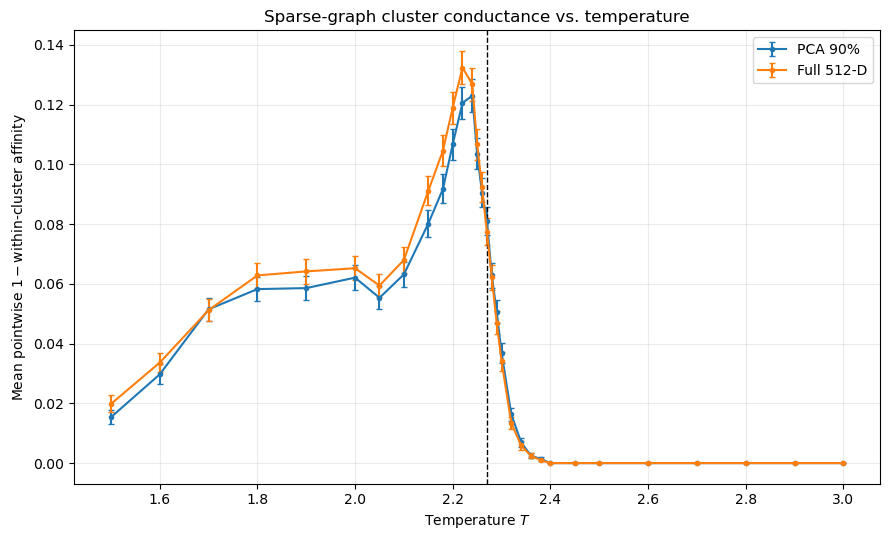

In [7]:
def summarize_escape(scores, method):
    frame = pd.DataFrame({
        "temperature": graph_temperatures,
        "escape": scores,
        "seed": np.repeat(np.arange(N_RUNS), N_TEMPERATURES),
    })
    grouped = frame.groupby("temperature")["escape"]
    result = grouped.agg(["mean", "std", "count"]).reset_index()
    result["sem"] = result["std"] / np.sqrt(result["count"])
    result["method"] = method
    return result

escape_summary = pd.concat([
    summarize_escape(pca_escape, "PCA 90%"),
    summarize_escape(full_escape, "Full 512-D"),
], ignore_index=True)
escape_summary.to_csv(
    OUTPUT_ROOT / "ising16_resnet18_raw_pointwise_conductance.csv", index=False
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for method in ("PCA 90%", "Full 512-D"):
    data = escape_summary[escape_summary["method"] == method]
    ax.errorbar(
        data["temperature"], data["mean"], yerr=data["sem"],
        marker="o", markersize=3, capsize=2, label=method,
    )
ax.axvline(2.0 / np.log(1.0 + np.sqrt(2.0)), color="black", linestyle="--", linewidth=1)
ax.set(
    xlabel="Temperature $T$",
    ylabel="Mean pointwise $1-$within-cluster affinity",
    title="Sparse-graph cluster conductance vs. temperature",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_conductance.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

## Unsupervised quality diagnostics

Silhouette score is estimated on a reproducible stratified sample because the exact all-pairs score for 310,000 configurations is computationally unnecessary.

In [8]:
rng = np.random.default_rng(42)
sample_indices = np.concatenate([
    rng.choice(
        np.flatnonzero(embedding_temperatures == temperature),
        size=min(500, np.sum(embedding_temperatures == temperature)),
        replace=False,
    )
    for temperature in temperatures
])

pca_silhouette = silhouette_score(
    np.asarray(pca90_scores)[sample_indices], pca_clusters[sample_indices]
)
full_silhouette = silhouette_score(
    np.asarray(embeddings)[sample_indices], full_clusters[sample_indices]
)

diagnostics = pd.DataFrame({
    "method": ["PCA 90%", "Full 512-D"],
    "silhouette_sample": [pca_silhouette, full_silhouette],
    "sample_size": [len(sample_indices), len(sample_indices)],
    "adjusted_mutual_information_between_methods": [
        adjusted_mutual_info_score(pca_clusters, full_clusters),
        adjusted_mutual_info_score(pca_clusters, full_clusters),
    ],
})
diagnostics.to_csv(OUTPUT_ROOT / "ising16_resnet18_raw_cluster_diagnostics.csv", index=False)
diagnostics

,method,silhouette_sample,sample_size,adjusted_mutual_information_between_methods
0,PCA 90%,0.359199,15500,0.925779
1,Full 512-D,0.315993,15500,0.925779
